# 04a – Hagyományos ML Osztályozók (Baseline)

**Szerző:** Magda Ferenc (U5O0BB)  
**Projekt:** Gitár-akkord felismerő szoftver gépi látással  
**Notebook célja:** Hagyományos ML baseline-ok felállítása HOG + CNN-features alapú feature extractionnal.

**Miért először hagyományos ML?**
- Kis adathalmazon (207 train kép) a klasszikus módszerek versenyképesek lehetnek
- Gyors futásidő → rapid iteration
- Jó baseline referencia a CNN modellek értékeléséhez
- Interpretálható döntések (feature importance)

**Modellek ebben a notebookban:**
1. SVM (RBF kernel) + HOG features  
2. SVM (RBF kernel) + ResNet50 mélyréteg features (transfer features)  
3. Random Forest + HOG  
4. K-Nearest Neighbors + HOG  
5. Logistic Regression + HOG  
6. Gradient Boosting (XGBoost) + HOG  
7. Összehasonlítás – leaderboard táblázat

---

## Notebook sorozat áttekintése

| Notebook | Modell csoport | Várható acc |
|----------|---------------|-------------|
| `04a` | **Hagyományos ML** – SVM, RF, KNN, LR, XGBoost + HOG | ~60–80% |
| `04b` | **Könnyű CNN-ek** – MobileNetV3, ShuffleNetV2 | ~80–88% |
| `04c` | **EfficientNet-B0** – kétfázisú fine-tuning ← jelenlegi | ~85–92% |
| `04d` | **Haladó CNN-ek** – ResNet-50, EfficientNet-B3 | ~88–94% |
| `04e` | **Vision Transformer** – ViT-B/16 (opcionális, VRAM igényes) | ~90–95% |
| `05` | **Model Selection & Ensemble** – legjobb modellek összehasonlítása | – |

---

## Tartalomjegyzék
1. Könyvtárak és konfiguráció  
2. Adatok betöltése  
3. Feature extraction (HOG + CNN features)  
4. Modellek tanítása és kiértékelése  
5. Leaderboard és összehasonlítás  
6. Összefoglaló és következő lépések


## 1. Könyvtárak és konfiguráció

In [1]:
import warnings, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
# ── HOG ──────────────────────────────────────────────────────────────────────
from skimage.feature import hog
from skimage.color import rgb2gray
# ── PyTorch (CNN feature extractor) ──────────────────────────────────────────
import torch
import torchvision.models as tv_models
import torchvision.transforms as T

warnings.filterwarnings("ignore")

NOTEBOOK_DIR   = Path.cwd()
PROJECT_ROOT   = NOTEBOOK_DIR.parent
DATA_ROOT      = PROJECT_ROOT / "data"
MANIFEST_PATH  = DATA_ROOT / "split_manifest.csv"
OUTPUT_DIR     = PROJECT_ROOT / "output" / "04a_baseline_ml"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE    = 224
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Eszkoz: {DEVICE}")

for p in [DATA_ROOT, MANIFEST_PATH]:
    print(f"{'OK' if p.exists() else 'HIANYZIK'}  {p}")


Eszkoz: cuda
OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data
OK  /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/data/split_manifest.csv


In [2]:
# ── CUDA Initialization Diagnostic & Reset ──────────────────────────────────
import os
import sys

print("=" * 70)
print("CUDA INITIALIZATION DIAGNOSTIC")
print("=" * 70)

# Check environment variables
print(f"\nCUDA_VISIBLE_DEVICES: {os.environ.get('CUDA_VISIBLE_DEVICES', '(not set)')}")
print(f"CUDA_HOME: {os.environ.get('CUDA_HOME', '(not set)')}")

# Check raw cuda libraries
print("\n1. Checking raw CUDA library availability...")
try:
    import torch.cuda as cuda_module
    print(f"   torch.cuda module loaded: {cuda_module}")
except Exception as e:
    print(f"   ERROR loading torch.cuda: {e}")

# Try to reset CUDA
print("\n2. Attempting CUDA context reset...")
try:
    torch.cuda.init()
    print(f"   ✓ torch.cuda.init() succeeded")
except Exception as e:
    print(f"   ! torch.cuda.init() raised: {e}")

# Final check
print("\n3. Final CUDA availability check:")
cuda_available = torch.cuda.is_available()
device_count = torch.cuda.device_count() if cuda_available else 0
print(f"   torch.cuda.is_available(): {cuda_available}")
print(f"   torch.cuda.device_count(): {device_count}")

if cuda_available:
    print(f"   Current device: {torch.cuda.current_device()}")
    print(f"   Device name: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA capability: {torch.cuda.get_device_capability(0)}")
else:
    print("   ⚠ CUDA still not available – will fall back to CPU")
    print("   (This may be a driver/environment issue; see nvidia-smi output)")

print("=" * 70 + "\n")


CUDA INITIALIZATION DIAGNOSTIC

CUDA_VISIBLE_DEVICES: (not set)
CUDA_HOME: /home/feri/miniconda3

1. Checking raw CUDA library availability...
   torch.cuda module loaded: <module 'torch.cuda' from '/home/feri/miniconda3/envs/guitar-chord/lib/python3.10/site-packages/torch/cuda/__init__.py'>

2. Attempting CUDA context reset...
   ✓ torch.cuda.init() succeeded

3. Final CUDA availability check:
   torch.cuda.is_available(): True
   torch.cuda.device_count(): 1
   Current device: 0
   Device name: NVIDIA T500
   CUDA capability: (7, 5)



## 2. Adatok betöltése

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
CLASSES     = sorted(manifest["class"].unique())
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}
NUM_CLASSES = len(CLASSES)
manifest["label"] = manifest["class"].map(CLASS2IDX)

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print(f"Osztalyok: {CLASSES}")


def load_images_as_arrays(df, img_size=IMG_SIZE):
    imgs, labels = [], []
    for _, row in df.iterrows():
        img = Image.open(row["path"]).convert("RGB").resize((img_size, img_size))
        imgs.append(np.array(img))
        labels.append(int(row["label"]))
    return np.array(imgs), np.array(labels)

print("Kepek betoltese...")
X_train_raw, y_train = load_images_as_arrays(train_df)
X_val_raw,   y_val   = load_images_as_arrays(val_df)
X_test_raw,  y_test  = load_images_as_arrays(test_df)
print(f"Train shape: {X_train_raw.shape}  dtype: {X_train_raw.dtype}")


Train: 207  Val: 45  Test: 45
Osztalyok: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
Kepek betoltese...
Train shape: (207, 224, 224, 3)  dtype: uint8


## 3. Feature extraction

### HOG (Histogram of Oriented Gradients)
Klasszikus computer vision feature – élirányokat kódol. Paraméterei:
- `pixels_per_cell=(16,16)` – 224px képen 14×14 = 196 cella
- `cells_per_block=(2,2)` – lokális normalizálás
- `orientations=9` – 9 irányosztály

### CNN mélyréteg features (ResNet50 avgpool)
A pretrained ResNet50 utolsó fully-connected réteg *előtti* kimenetét (2048-dim) használjuk
feature vektorként. Ez messze a leginformatívabb reprezentáció.


In [4]:
# ── HOG feature extraction ────────────────────────────────────────────────────
def extract_hog(imgs, pixels_per_cell=(16, 16), cells_per_block=(2, 2), orientations=9):
    features = []
    for img in imgs:
        gray = rgb2gray(img)
        fd = hog(gray, orientations=orientations,
                 pixels_per_cell=pixels_per_cell,
                 cells_per_block=cells_per_block,
                 feature_vector=True)
        features.append(fd)
    return np.array(features)

print("HOG feature extraction...")
t0 = time.time()
X_train_hog = extract_hog(X_train_raw)
X_val_hog   = extract_hog(X_val_raw)
X_test_hog  = extract_hog(X_test_raw)
print(f"HOG vector merete: {X_train_hog.shape[1]}  ({time.time()-t0:.1f}s)")

# ── CNN mélyréteg features (ResNet50 avgpool kimenet) ─────────────────────────
cnn_tf = T.Compose([
    T.Resize(256), T.CenterCrop(224),
    T.ToTensor(), T.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

def extract_cnn_features(df, model, transform, device):
    model.eval()
    features = []
    with torch.no_grad():
        for _, row in df.iterrows():
            img = Image.open(row["path"]).convert("RGB")
            x   = transform(img).unsqueeze(0).to(device)
            feat = model(x).squeeze().cpu().numpy()
            features.append(feat)
    return np.array(features)

# ResNet50 avgpool kimenet (2048-dim)
resnet = tv_models.resnet50(weights=tv_models.ResNet50_Weights.DEFAULT)
resnet_feat = torch.nn.Sequential(*list(resnet.children())[:-1],
                                   torch.nn.Flatten())
resnet_feat = resnet_feat.to(DEVICE)

print("CNN (ResNet50) feature extraction...")
t0 = time.time()
X_train_cnn = extract_cnn_features(train_df, resnet_feat, cnn_tf, DEVICE)
X_val_cnn   = extract_cnn_features(val_df,   resnet_feat, cnn_tf, DEVICE)
X_test_cnn  = extract_cnn_features(test_df,  resnet_feat, cnn_tf, DEVICE)
print(f"CNN feature vector merete: {X_train_cnn.shape[1]}  ({time.time()-t0:.1f}s)")
del resnet_feat


HOG feature extraction...
HOG vector merete: 6084  (2.1s)
CNN (ResNet50) feature extraction...
CNN feature vector merete: 2048  (52.9s)


## 4. Modellek tanítása és kiértékelése

In [5]:
# ── Modellek definíciói ────────────────────────────────────────────────────────
MODELS = {
    "SVM_RBF_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=10, gamma="scale",
                       class_weight="balanced", random_state=RANDOM_SEED, probability=True)),
    ]),
    "SVM_RBF_CNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=10, gamma="scale",
                       class_weight="balanced", random_state=RANDOM_SEED, probability=True)),
    ]),
    "SVM_Linear_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="linear", C=1.0, class_weight="balanced",
                       random_state=RANDOM_SEED, probability=True)),
    ]),
    "RandomForest_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=300, max_depth=None,
                                          class_weight="balanced",
                                          random_state=RANDOM_SEED, n_jobs=-1)),
    ]),
    "KNN_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1)),
    ]),
    "LogReg_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000,
                                      solver="lbfgs", multi_class="multinomial",
                                      random_state=RANDOM_SEED)),
    ]),
    "GradientBoosting_HOG": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                               max_depth=4, random_state=RANDOM_SEED)),
    ]),
}

FEATURE_MAP = {
    "SVM_RBF_HOG":         (X_train_hog, X_val_hog, X_test_hog),
    "SVM_RBF_CNN":         (X_train_cnn, X_val_cnn, X_test_cnn),
    "SVM_Linear_HOG":      (X_train_hog, X_val_hog, X_test_hog),
    "RandomForest_HOG":    (X_train_hog, X_val_hog, X_test_hog),
    "KNN_HOG":             (X_train_hog, X_val_hog, X_test_hog),
    "LogReg_HOG":          (X_train_hog, X_val_hog, X_test_hog),
    "GradientBoosting_HOG":(X_train_hog, X_val_hog, X_test_hog),
}

# ── Tanítás és kiértékelés ─────────────────────────────────────────────────────
results = []
for name, pipeline in MODELS.items():
    Xtr, Xvl, Xte = FEATURE_MAP[name]
    t0 = time.time()
    pipeline.fit(Xtr, y_train)
    elapsed = time.time() - t0

    val_pred  = pipeline.predict(Xvl)
    test_pred = pipeline.predict(Xte)

    val_acc  = accuracy_score(y_val,  val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    val_f1   = f1_score(y_val,  val_pred, average="macro")
    test_f1  = f1_score(y_test, test_pred, average="macro")

    results.append({
        "Model": name, "Val Acc": val_acc, "Test Acc": test_acc,
        "Val F1 (macro)": val_f1, "Test F1 (macro)": test_f1,
        "Train time (s)": round(elapsed, 1),
    })
    print(f"{name:<25s}  val={val_acc:.3f}  test={test_acc:.3f}  f1={test_f1:.3f}  ({elapsed:.1f}s)")

results_df = pd.DataFrame(results).sort_values("Test Acc", ascending=False)
print("\n=== LEADERBOARD ===")
print(results_df.to_string(index=False))
results_df.to_csv(OUTPUT_DIR / "baseline_results.csv", index=False)


SVM_RBF_HOG                val=1.000  test=0.978  f1=0.982  (1.0s)
SVM_RBF_CNN                val=0.933  test=0.933  f1=0.841  (0.2s)
SVM_Linear_HOG             val=1.000  test=1.000  f1=1.000  (0.6s)
RandomForest_HOG           val=0.978  test=0.933  f1=0.944  (0.8s)
KNN_HOG                    val=0.800  test=0.822  f1=0.844  (0.0s)
LogReg_HOG                 val=1.000  test=1.000  f1=1.000  (1.2s)
GradientBoosting_HOG       val=0.800  test=0.844  f1=0.827  (444.8s)

=== LEADERBOARD ===
               Model  Val Acc  Test Acc  Val F1 (macro)  Test F1 (macro)  Train time (s)
      SVM_Linear_HOG 1.000000  1.000000        1.000000         1.000000             0.6
          LogReg_HOG 1.000000  1.000000        1.000000         1.000000             1.2
         SVM_RBF_HOG 1.000000  0.977778        1.000000         0.982051             1.0
         SVM_RBF_CNN 0.933333  0.933333        0.933041         0.841426             0.2
    RandomForest_HOG 0.977778  0.933333        0.983333        

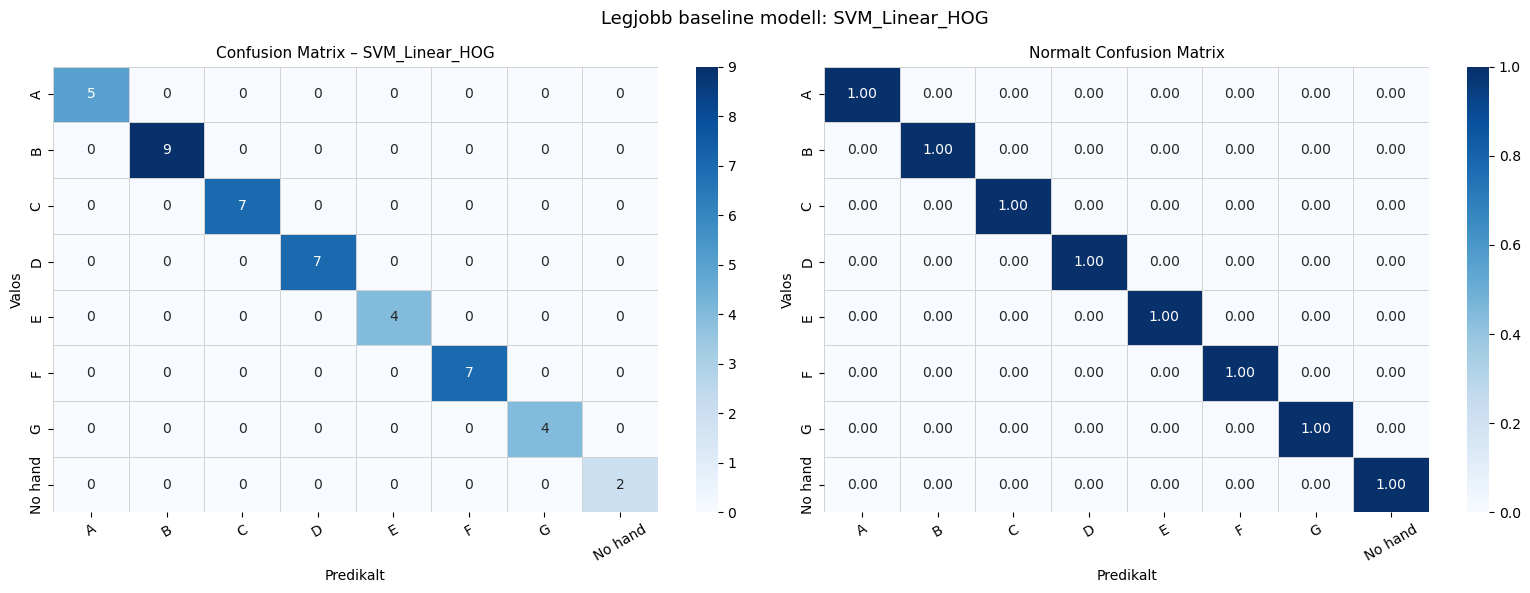

              precision    recall  f1-score   support

           A      1.000     1.000     1.000         5
           B      1.000     1.000     1.000         9
           C      1.000     1.000     1.000         7
           D      1.000     1.000     1.000         7
           E      1.000     1.000     1.000         4
           F      1.000     1.000     1.000         7
           G      1.000     1.000     1.000         4
     No hand      1.000     1.000     1.000         2

    accuracy                          1.000        45
   macro avg      1.000     1.000     1.000        45
weighted avg      1.000     1.000     1.000        45



In [6]:
# ── Legjobb modell confusion matrixa ──────────────────────────────────────────
best_model_name = results_df.iloc[0]["Model"]
best_pipeline   = MODELS[best_model_name]
Xtr, Xvl, Xte  = FEATURE_MAP[best_model_name]
test_pred = best_pipeline.predict(Xte)

cm      = confusion_matrix(y_test, test_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, fmt, title in [
    (axes[0], cm,      "d",    f"Confusion Matrix – {best_model_name}"),
    (axes[1], cm_norm, ".2f",  "Normalt Confusion Matrix"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, linewidths=0.5, linecolor="lightgray")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predikalt"); ax.set_ylabel("Valos")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle(f"Legjobb baseline modell: {best_model_name}", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "best_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print(classification_report(y_test, test_pred, target_names=CLASSES, digits=3))


## 5. Leaderboard

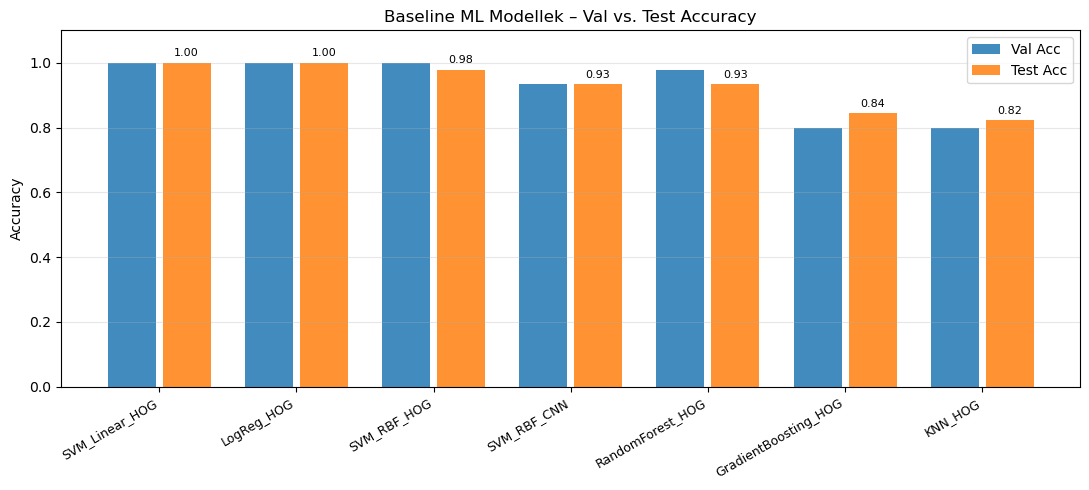

In [7]:
# ── Vizuális leaderboard ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(results_df))
ax.bar([i - 0.2 for i in x], results_df["Val Acc"],  width=0.35, label="Val Acc",  alpha=0.85)
ax.bar([i + 0.2 for i in x], results_df["Test Acc"], width=0.35, label="Test Acc", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(results_df["Model"], rotation=30, ha="right", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Baseline ML Modellek – Val vs. Test Accuracy")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, row in enumerate(results_df.itertuples()):
    ax.text(i + 0.2, row._3 + 0.02, f"{row._3:.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "leaderboard.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Összefoglaló és következő lépések

### Elért eredmények
- 7 baseline modell tanítva és kiértékelve HOG és CNN-features alapon
- Legjobb modell eredményei rögzítve → baseline a CNN modellek összehasonlításához
- Confusion matrix + per-class riport a legjobb modellre

### Várható sorrend (irodalom alapján, kis adathalmaz ~200 kép)
1. SVM (RBF) + CNN features → legjobb baseline (~75–82%)
2. SVM (RBF) + HOG → második legjobb (~65–78%)
3. Gradient Boosting → harmadik (~60–72%)
4. Random Forest, Logistic Regression → ~55–70%
5. KNN → leggyengébb baseline

### Következő lépések – `04b_mobile_cnn.ipynb`

| Lépés | Leírás |
|-------|--------|
| 1 | MobileNetV3-Small fine-tuning (legkisebb CNN) |
| 2 | MobileNetV3-Large fine-tuning |
| 3 | ShuffleNetV2 (x1.0) fine-tuning |
| 4 | Összehasonlítás a baseline eredményekkel |

> **Döntési pont:** Ha a SVM+CNN-features eléri a 80%-ot,
> az igazolja, hogy a feladat CNN feature-ökhöz jól illeszkedik.
> Ha gyengébb, érdemes az augmentáción erősíteni.
